Modified from "Using Deep Learning for Flexible and Scalable Earthquake Forecasting"  
Reference: [Zenodo](https://zenodo.org/records/8161777)

In [257]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import functools
import os
import importlib
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [258]:
checkpoint_dir  =  Path("../checkpoints/rtpp_20251211-203313") 
checkpoint_path1 = checkpoint_dir/ "best_model_1.pth"
checkpoint_dir2 = Path("../checkpoints/nhpp_20251208-165235") 
checkpoint_path2 = checkpoint_dir2/ "last_model_1.pth"

## Loading a trained model

In [259]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_and_prepare_model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model, args = load_and_prepare_model(checkpoint_path=checkpoint_path1,device=device)
# model2,_ = load_and_prepare_model(checkpoint_path=checkpoint_path2,device=device)

load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'rtpp', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'bg_model': 'mamba', 'bg_model_cfg': {'d_feature': 1, 'd_state': 64, 'd_model': 16, 'model_type': 'mamba', 'scale_init': 400.0}, 'batch_size': 1, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'none', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'rnn_type': 'GRU', 'd_model': 32, 'rnn_dropout': 0.3, 'num_components': 32, 'scale_range': 'decay', 'dim': 1, 'epochs': 500, 'save_dir': 'checkpoints/rtpp_20251211-203313', 'cuda_id': '0', 'dataset': 'PNR', 'seed': 0, 'minibatch_training': False, 'split_by_time': True, 'time_order': ['train', 'val', 'test'], 'cuda': True, 'tau_mean': 0.21783232688903809, 'tau_min': 9.198001293952984e-08, 'tau_ma

In [260]:
# model.bg_model = model2.bg_model

In [261]:
model.bg_model._scale

tensor(377.6179, device='cuda:0', grad_fn=<ExpBackward0>)

## Loading the catalog

In [262]:
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw',catalog_file=None)

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/PNR/raw.


In [263]:
catalog_ds.full_sequence

Sequence(
  inter_times: [6156],
  arrival_times: [6155],
  t_start: 0.0,
  t_end: 1548.0,
  t_nll_start: 0.0,
  mag: [6155],
  loc: [6155, 2],
  depth: [6155],
  time_series: [92316, 1],
  time_series_times: [92316]
)

## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

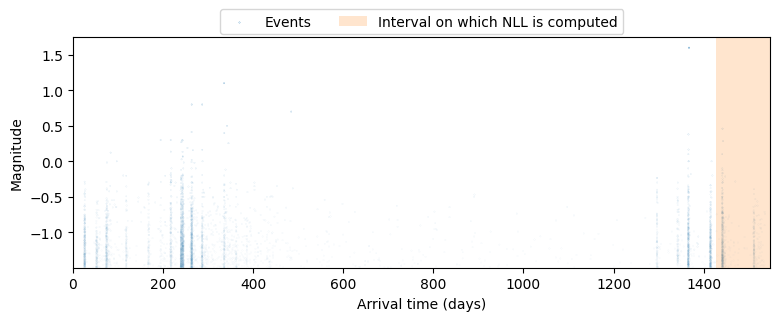

In [264]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
train_seq = catalog_ds.train[0]
visualize_sequence(test_seq, show_nll=True)

In [265]:
test_batch = src.data.Batch.from_list([test_seq])
test_batch.to(device)
train_batch = src.data.Batch.from_list([train_seq])
train_batch.to(device)

Batch(
  inter_times: [1, 4097],
  arrival_times: [1, 4097],
  t_start: [1],
  t_end: [1],
  t_nll_start: [1],
  nll_event_mask: [1, 4097],
  input_mask: [1, 4097],
  start_idx: [1],
  end_idx: [1],
  non_pad_mask: [1, 4097],
  type_seq: [1, 4097],
  mag: [1, 4097],
  loc: [1, 4097, 2],
  depth: [1, 4097],
  time_series: [1, 54001, 1],
  time_series_times: [1, 54001]
)

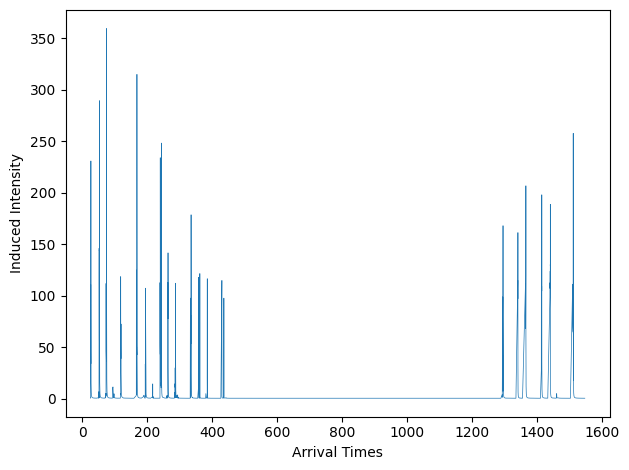

In [266]:
f_intensity= model.bg_model.intensity(test_batch)
plt.plot(
    test_batch.arrival_times.reshape(-1).detach().cpu().numpy(),
    f_intensity.reshape(-1).detach().cpu().numpy(),
    linewidth=0.5,
    color='tab:blue'
)
plt.xlabel('Arrival Times')
plt.ylabel('Induced Intensity')
plt.tight_layout()
plt.savefig(checkpoint_dir/'induced_intensity.png')

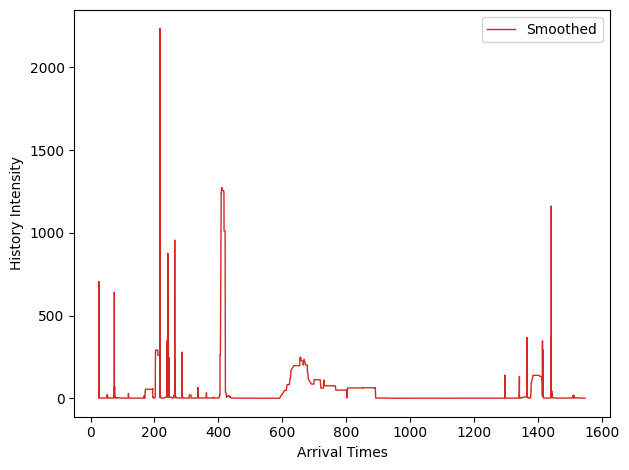

In [267]:
context = model.get_context(test_batch)
inter_time_dist = model.get_inter_time_dist(context)
log_h_intensity = inter_time_dist.log_hazard(test_batch.inter_times.clamp_min(1e-10))
h_intensity = torch.exp(log_h_intensity)
h_intensity_copied = torch.where(h_intensity > 100000, torch.tensor(0.0, device=h_intensity.device), h_intensity)

window = 20  # smoothing window size
arrival_times_np = test_batch.arrival_times.detach().cpu().numpy().ravel()
raw_np = h_intensity_copied.detach().cpu().numpy().ravel()
smoothed = np.convolve(raw_np, np.ones(window) / window, mode='same')

plt.xlabel('Arrival Times')
plt.ylabel('History Intensity')
# plt.plot(arrival_times_np, raw_np, linewidth=0.5, color='tab:blue', label='Raw')
plt.plot(arrival_times_np, smoothed, linewidth=1.0, color='tab:red', label='Smoothed')
plt.legend()
plt.tight_layout()

In [268]:
(h_intensity > 1000).sum().item()

69

We would like to generate a 30-day forecast for the interval `[13000, 13030]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 13000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[13000, 13030]`.

In [298]:
t_forecast = 1430 # 1460
duration = 100 # 7 30
num_samples = 10000 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(0, t_forecast) #  3500
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration)

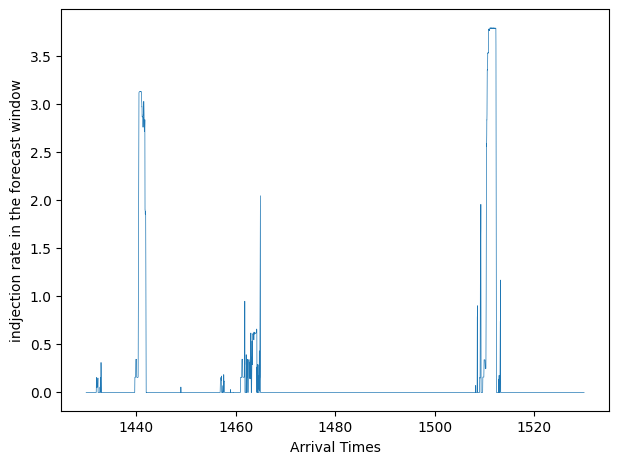

In [299]:
mask  = (test_seq.time_series_times >= t_forecast) & (test_seq.time_series_times < t_forecast + duration)
future_time_series = test_seq.time_series[mask]
future_time_series_times = test_seq.time_series_times[mask]
plt.xlabel('Arrival Times')
plt.ylabel('indjection rate in the forecast window')
plt.tight_layout()
plt.plot(future_time_series_times,
          future_time_series.reshape(-1).detach().cpu().numpy(),
           linewidth=0.5,
         color='tab:blue')

## Generate the forecast

In [300]:
past_batch = src.data.Batch.from_list([past_seq.float()])

In [301]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

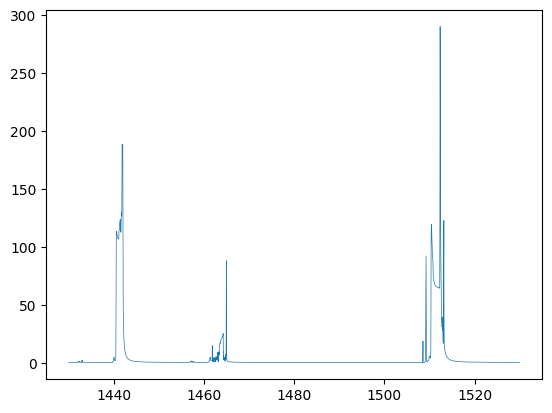

In [302]:
model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))
model.bg_model.ts_batch_cache
times_all = test_seq.time_series_times
mask = (times_all >= t_forecast) & (times_all < t_forecast + duration)
f_intensity = model.bg_model.intensity(ts_batch=model.bg_model.ts_batch_cache,t_query=times_all[mask].unsqueeze(0))
plt.plot(times_all[mask], f_intensity.reshape(-1).detach().cpu().numpy(), linewidth=0.5, color='tab:blue')

838

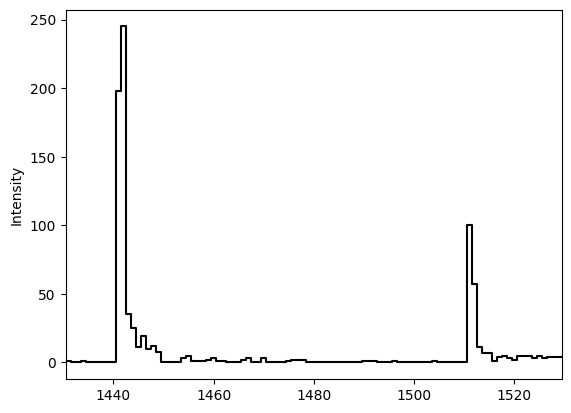

In [303]:
from src.utils.visualization import  plot_intensity
plot_intensity(observed_seq,dt=1)
len(observed_seq)

In [304]:
model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))

In [305]:
model.nll_loss(train_batch)

f_intensity max:     359.6806945800781, h_intensity max: 43910.84375
nll_bg mean: -1469.4029541015625, nll_total mean: -6740.654296875


tensor([[-9.0600]], device='cuda:0', grad_fn=<DivBackward0>)

In [306]:
set_seed(4) 
model.eval()  # Set the model to evaluation mode

all_forecasts = []
samples_per_batch = 10000
for _ in range(num_samples // samples_per_batch):
    # forecast = model.sample_with_cache(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    # forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True, max_sample_len=4000)
    forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    all_forecasts.extend(forecast)

/root/autodl-tmp/chuandian_eq/src/data/sequence.py:234: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:234: UserWarning: Found 2 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


In [307]:
all_forecasts

[Sequence(
   inter_times: [797],
   arrival_times: [796],
   t_start: 1430.0,
   t_end: 1530.0,
   t_nll_start: 1430.0,
   mag: [796]
 ),
 Sequence(
   inter_times: [773],
   arrival_times: [772],
   t_start: 1430.0,
   t_end: 1530.0,
   t_nll_start: 1430.0,
   mag: [772]
 ),
 Sequence(
   inter_times: [725],
   arrival_times: [724],
   t_start: 1430.0,
   t_end: 1530.0,
   t_nll_start: 1430.0,
   mag: [724]
 ),
 Sequence(
   inter_times: [844],
   arrival_times: [843],
   t_start: 1430.0,
   t_end: 1530.0,
   t_nll_start: 1430.0,
   mag: [843]
 ),
 Sequence(
   inter_times: [820],
   arrival_times: [819],
   t_start: 1430.0,
   t_end: 1530.0,
   t_nll_start: 1430.0,
   mag: [819]
 ),
 Sequence(
   inter_times: [783],
   arrival_times: [782],
   t_start: 1430.0,
   t_end: 1530.0,
   t_nll_start: 1430.0,
   mag: [782]
 ),
 Sequence(
   inter_times: [810],
   arrival_times: [809],
   t_start: 1430.0,
   t_end: 1530.0,
   t_nll_start: 1430.0,
   mag: [809]
 ),
 Sequence(
   inter_times: 

In [308]:
zero_indices = []
for idx, fc in enumerate(all_forecasts):
    t = torch.as_tensor(fc.inter_times).cpu()
    if (t == 0).any():
        zero_indices.append(idx)

if zero_indices:
    print("Found zeros in inter_times at indices:", zero_indices)
else:
    print("No zeros found in inter_times of any forecast.")
print("Number of forecasts with zero inter_times:", len(zero_indices))

Found zeros in inter_times at indices: [2, 3, 53, 75, 98, 109, 162, 171, 202, 221, 236, 245, 250, 287, 368, 393, 464, 508, 515, 612, 716, 717, 729, 733, 793, 818, 839, 853, 859, 909, 954, 1000, 1109, 1127, 1138, 1151, 1153, 1169, 1170, 1186, 1198, 1273, 1276, 1370, 1442, 1445, 1447, 1452, 1528, 1632, 1676, 1698, 1706, 1711, 1730, 1733, 1740, 1815, 1829, 1898, 1911, 1999, 2197, 2199, 2207, 2233, 2234, 2298, 2306, 2339, 2354, 2367, 2400, 2401, 2498, 2524, 2585, 2696, 2707, 2724, 2731, 2746, 2766, 2796, 2807, 2827, 2829, 2893, 2909, 2912, 2931, 2944, 2980, 2991, 3028, 3048, 3067, 3093, 3247, 3252, 3280, 3283, 3319, 3321, 3426, 3427, 3497, 3507, 3578, 3722, 3737, 3740, 3741, 3746, 3759, 3775, 3811, 3819, 3824, 3825, 3883, 3939, 3964, 3968, 3993, 4024, 4091, 4103, 4174, 4175, 4279, 4299, 4330, 4333, 4348, 4354, 4437, 4493, 4507, 4518, 4537, 4570, 4591, 4664, 4686, 4716, 4736, 4744, 4804, 4807, 4821, 4824, 4876, 5119, 5133, 5151, 5174, 5197, 5201, 5225, 5230, 5308, 5317, 5319, 5339, 5425, 54

`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[13000, 13030]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

In [309]:
# importlib.reload(src.utils.visualization)

In [310]:
model.bg_model.forecast_count(t_forecast, t_forecast + duration)

tensor(561.5608, device='cuda:0')

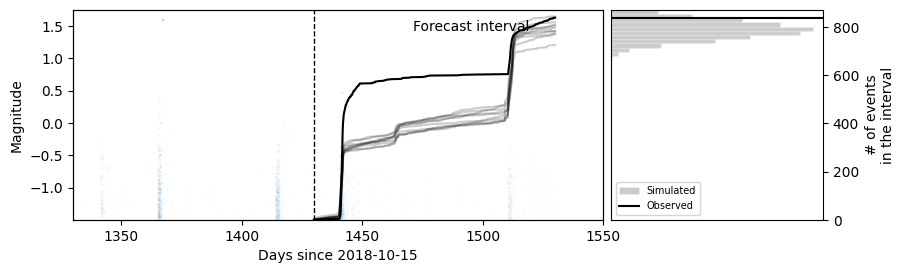

In [311]:
date_str = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d')
src.utils.visualization.visualize_trajectories(test_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.pdf",figsize=(10,3),xlabel='Days since '+date_str)
# src.utils.visualization.visualize_trajectories(train_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.png")

In [312]:
import  src.utils.catalog_tests as catalog_tests

In [313]:
test_seq

Sequence(
  inter_times: [6156],
  arrival_times: [6155],
  t_start: 0.0,
  t_end: 1548.0,
  t_nll_start: 1428.0,
  mag: [6155],
  loc: [6155, 2],
  depth: [6155],
  time_series: [92192, 1],
  time_series_times: [92192]
)

N-test

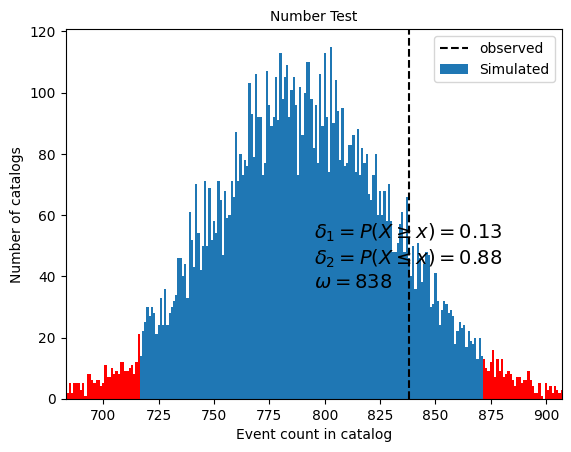

In [314]:
number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=len(observed_seq),                   
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False
)
ax= number_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'n_test.pdf')

M-test

In [315]:
config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 10,
    'dmw': 0.01
}

magnitude_bins, distribution = catalog_tests.compute_magnitude_distribution(
    forecast[0].mag.cpu().numpy(), 
   **config_dict
)

In [316]:
get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu())),
    verbose=False
)


IndexError: index -1 is out of bounds for axis 0 with size 0

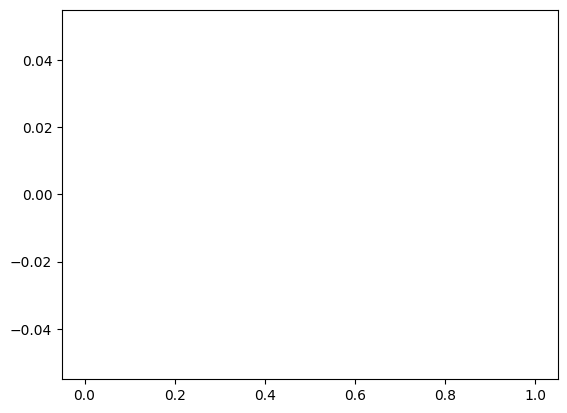

In [317]:
magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
   obs_name='observed',
    sim_name='Simulated',
    plot=False
)
magnitude_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'m_test.pdf')

In [ ]:
checkpoint_dir

PosixPath('../checkpoints/rtpp_20251125-223019')